#Lab 10 Practice Tasks

#TASK # 1
Imagine you&#39;re a data scientist working for a real estate company. Your task is to build a model to predict house prices based on various features such as the number of bedrooms, square footage, and the location of the house. You have access to a dataset with information about houses, including their square footage, number of bedrooms, number of bathrooms, age of the house, and location (neighborhood). The goal is to predict the price of the house, which is a continuous variable.    
Perform the following task:  
● Clean the dataset and handle any missing values. Encode categorical variables (e.g., neighborhood) as numeric values.  
● Identify the relevant features that most likely impact the price.  
● Evaluate the performance of the model using any metrics.  
● Predict the price of a house given a new set of features.  

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Housing.csv')
print(df.head())
print(f"\nShape: {df.shape}")


print("\nMissing Values:\n", df.isnull().sum())

binary_cols = ['mainroad', 'guestroom', 'basement','hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

le = LabelEncoder()
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])

print("\nEncoded furnishingstatus:", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nDataset after encoding:\n", df.head())

x = df.drop('price', axis=1).values
y = df['price'].values

print("\nFeatures used:", df.drop('price', axis=1).columns.tolist())

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("Feature scaling applied using StandardScaler.")

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)
print(f"\nTrain size: {len(x_train)}, Test size: {len(x_test)}")

LR      = LinearRegression()
ModelLR = LR.fit(x_train, y_train)

PredictionLR = ModelLR.predict(x_test)

print("\nPredictions:", PredictionLR[:5])

print('\nLR Testing Accuracy')
teachLR      = r2_score(y_test, PredictionLR)
testingAccLR = teachLR * 100
print(f"R2 Score (Testing Accuracy): {testingAccLR:.2f}%")

rmse = np.sqrt(mean_squared_error(y_test, PredictionLR))
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

new_house = pd.DataFrame([{
    'area':             5000,
    'bedrooms':         3,
    'bathrooms':        2,
    'stories':          2,
    'mainroad':         1,
    'guestroom':        0,
    'basement':         1,
    'hotwaterheating':  0,
    'airconditioning':  1,
    'parking':          1,
    'prefarea':         0,
    'furnishingstatus': 1
}])

new_house_scaled = scaler.transform(new_house)
predicted_price  = ModelLR.predict(new_house_scaled)

print('\n New House Prediction')
print(f"Predicted House Price: {predicted_price[0]:,.2f}")

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Shape: (545, 13)

Missing Values:
 price               0
area                0
bedrooms           

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


#TASK # 2
You work as a data scientist for an email service provider. Your task is to develop a model that can classify emails as spam or not spam based on their content. You have a labeled dataset with thousands of emails. Each email has features such as frequency of specific words, length of the email, presence of hyperlinks, and sender&#39;s address. The task is to classify an email as spam (1) or not spam (0).  
● Preprocess the dataset by converting text features to numerical features.    
● Train a model to classify the emails based on their features.  
● Evaluate the model&#39;s performance.  
● Deploy the model to classify new incoming emails.

In [6]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())
print(f"\nDataset Shape: {df.shape}")
print("\nClass Distribution:")
print(df['label'].value_counts())

df['label_encoded'] = (df['label'] == 'spam').astype(int)

df['word_count']     = df['message'].apply(lambda x: len(x.split()))
df['char_count']     = df['message'].apply(lambda x: len(x))
df['has_hyperlink']  = df['message'].apply(lambda x: int('http' in x.lower()))
df['has_free']       = df['message'].apply(lambda x: int('free' in x.lower()))
df['has_win']        = df['message'].apply(lambda x: int('win' in x.lower()))
df['has_urgent']     = df['message'].apply(lambda x: int('urgent' in x.lower()))
df['exclaim_count']  = df['message'].apply(lambda x: x.count('!'))
df['digit_count']    = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['upper_count']    = df['message'].apply(lambda x: sum(c.isupper() for c in x))

print("\nMissing Values:\n", df.isnull().sum())

x = df[['word_count', 'char_count', 'has_hyperlink', 'has_free',
         'has_win', 'has_urgent', 'exclaim_count',
         'digit_count', 'upper_count']].values
y = df['label_encoded'].values

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("\nFeature scaling applied using StandardScaler.")

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("\nSVM Accuracy:", accuracy_score(y_test, y_pred))

print('\nSVM Testing Accuracy')
testingAccSVM = accuracy_score(y_test, y_pred) * 100
print(f"Testing Accuracy: {testingAccSVM:.2f}%")

new_email = pd.DataFrame({
    'word_count':    [20],
    'char_count':    [120],
    'has_hyperlink': [1],
    'has_free':      [1],
    'has_win':       [1],
    'has_urgent':    [1],
    'exclaim_count': [3],
    'digit_count':   [5],
    'upper_count':   [10]
})

new_email_scaled = scaler.transform(new_email)
email_prediction = svm.predict(new_email_scaled)

print('\nNew Email Classification')
print("Email classified as:", "SPAM" if email_prediction[0] == 1 else "NOT SPAM")


  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing Values:
 label            0
message          0
label_encoded    0
word_count       0
char_count       0
has_hyperlink    0
has_free         0
has_win          0
has_urgent       0
exclaim_count    0
digit_count      0
upper_count      0
dtype: int64

Feature scaling applied using StandardScaler.

Train size: 3900, Test size: 1672

SVM Accuracy: 0.9808612440191388

SVM Testing Accuracy
Testing Accuracy: 98.09%

New Email Classification
Email classified as: SPAM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


#TASK # 3
You work for a retail business and your task is to classify customers into two categories:
high-value and low-value customers. The classification is based on customer features
such as total spending in the last 6 months, age, number of visits, and purchase
frequency. You have a dataset with customer information, including spending habits,
frequency of visits, and demographics. The goal is to classify customers into high-value
(1) and low-value (0) categories.   
● Clean the dataset and handle any missing or outlier values. Perform feature scaling if necessary.    
● Divide the dataset into a training set and a testing set.           
● Find a separating hyperplane for classification.          
● Find rules that classify customers based on their features.           
● Evaluate the performance of the model.

In [8]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('marketing_campaign.csv', sep=';')

print(df.head())
print(f"\nDataset Shape: {df.shape}")

print("\nMissing Values:\n", df.isnull().sum())
df = df.dropna(subset=['Income'])
print(f"\nDataset size after dropping missing rows: {len(df)}")


df['TotalSpending'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

median_spending = df['TotalSpending'].median()
df['label'] = (df['TotalSpending'] > median_spending).astype(int)

print(f"\nMedian Spending: {median_spending:.2f}")
print("Class Distribution:\n", df['label'].value_counts())

features = ['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'TotalSpending']

x = df[features].copy()
y = df['label'].values

Q1  = x['Income'].quantile(0.25)
Q3  = x['Income'].quantile(0.75)
IQR = Q3 - Q1
x   = x[(x['Income'] >= Q1 - 1.5 * IQR) &
         (x['Income'] <= Q3 + 1.5 * IQR)]
y   = df.loc[x.index, 'label'].values
x   = x.values

print(f"\nDataset size after outlier removal: {len(x)}")

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(x_train)}, Testing samples: {len(x_test)}")


svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)
print("\nSVM Predictions (sample):", y_pred_svm[:10])

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
testingAccSVM = accuracy_score(y_test, y_pred_svm) * 100
print(f"Testing Accuracy: {testingAccSVM:.2f}%")


DT = DecisionTreeClassifier()


ModelDT = DT.fit(x_train, y_train)
PredictionDT = DT.predict(x_test)
print("\nPredictions:", PredictionDT[:10])

print('DT Training Accuracy')
tracDT        = DT.score(x_train, y_train)
TrainingAccDT = tracDT * 100
print(f"Training Accuracy: {TrainingAccDT:.2f}%")

print('DT Testing Accuracy')
teacDT        = accuracy_score(y_test, PredictionDT)
testingAccDT  = teacDT * 100
print(f"Testing Accuracy: {testingAccDT:.2f}%")

new_customer = pd.DataFrame({
    'Income':             [75000],
    'Recency':            [20],
    'NumDealsPurchases':  [3],
    'NumWebPurchases':    [8],
    'NumStorePurchases':  [6],
    'NumWebVisitsMonth':  [4],
    'TotalSpending':      [1200]
})

new_customer_scaled      = scaler.transform(new_customer)
svm_result               = svm.predict(new_customer_scaled)
dt_result                = DT.predict(new_customer_scaled)

print('\nNew Customer Classification')
print("SVM Classification        :", "High-Value" if svm_result[0] == 1 else "Low-Value")
print("Decision Tree Classification:", "High-Value" if dt_result[0] == 1 else "Low-Value")


     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


#Lab 11 Practice Tasks

#TASK # 1  
In the example code above, customer segmentation was performed using only two
features. Now, use all available features except customer_id to implement K-Means
clustering. Perform the clustering twice — once without feature scaling, and once with
scaling applied to all features except age. Compare the results and comment on the
differences and insights observed from these changes.

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape: (200, 5)

Column Names: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing Values:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

CLUSTERING WITHOUT SCALING


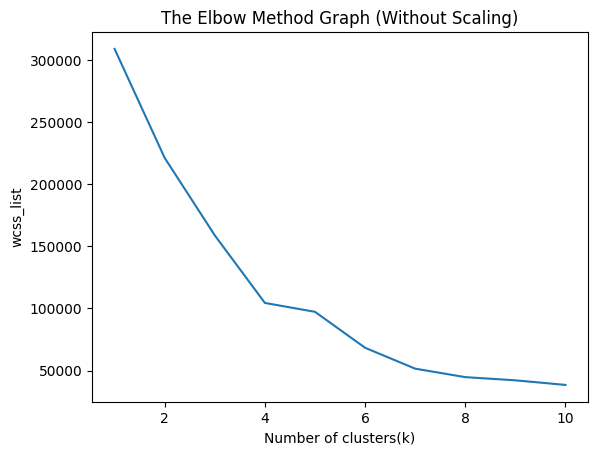

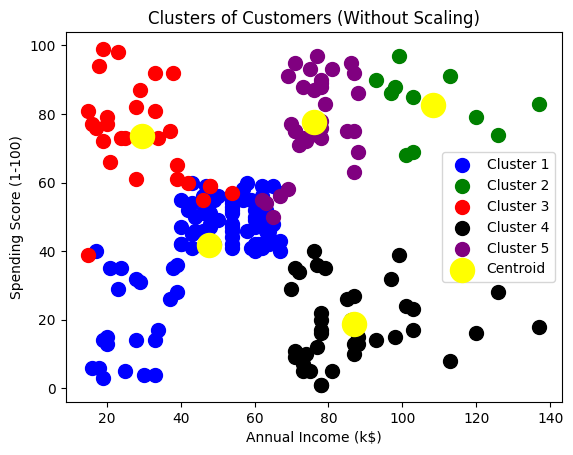

Cluster labels (without scaling): [2 2 0 2 0 2 0 2 0 2]

CLUSTERING WITH SCALING (except Age)


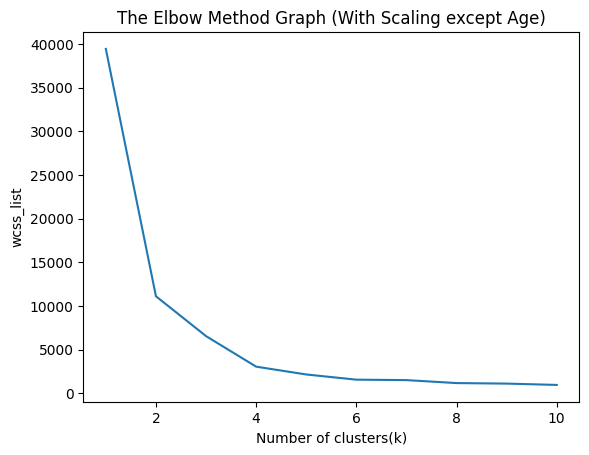

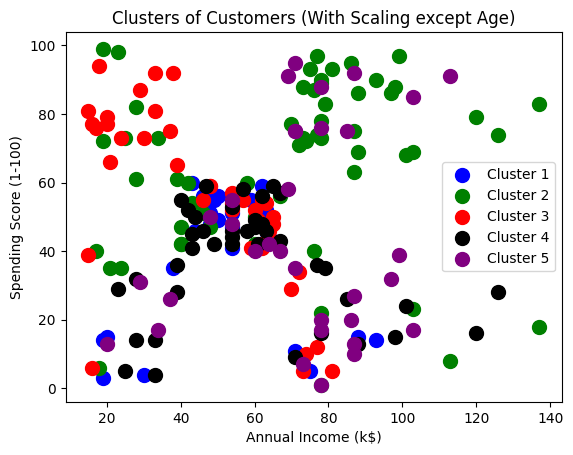

Cluster labels (with scaling): [2 2 2 2 1 2 1 2 0 1]


In [10]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('Mall_Customers.csv')
df.head()

print(df.head())
print(f"\nDataset Shape: {df.shape}")
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Genre'])

x = df[['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values


print("\nCLUSTERING WITHOUT SCALING")

wcss_list = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 11), wcss_list)
mtp.title('The Elbow Method Graph (Without Scaling)')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

kmeans     = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_predict  = kmeans.fit_predict(x)

mtp.scatter(x[y_predict == 0, 2], x[y_predict == 0, 3], s=100, c='blue',   label='Cluster 1')  #for first cluster
mtp.scatter(x[y_predict == 1, 2], x[y_predict == 1, 3], s=100, c='green',  label='Cluster 2')  #for second cluster
mtp.scatter(x[y_predict == 2, 2], x[y_predict == 2, 3], s=100, c='red',    label='Cluster 3')  #for third cluster
mtp.scatter(x[y_predict == 3, 2], x[y_predict == 3, 3], s=100, c='black',  label='Cluster 4')  #for fourth cluster
mtp.scatter(x[y_predict == 4, 2], x[y_predict == 4, 3], s=100, c='purple', label='Cluster 5')  #for fifth cluster
mtp.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s=300, c='yellow', label='Centroid')
mtp.title('Clusters of Customers (Without Scaling)')
mtp.xlabel('Annual Income (k$)')
mtp.ylabel('Spending Score (1-100)')
mtp.legend()
mtp.show()

print("Cluster labels (without scaling):", y_predict[:10])

print("\nCLUSTERING WITH SCALING (except Age)")

x_to_scale = df[['Gender_encoded', 'Annual Income (k$)', 'Spending Score (1-100)']].values
x_age      = df[['Age']].values

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(x_to_scale)
X_combined = nm.hstack([X_scaled, x_age])

wcss_list = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_combined)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 11), wcss_list)
mtp.title('The Elbow Method Graph (With Scaling except Age)')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

kmeans    = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_predict = kmeans.fit_predict(X_combined)

mtp.scatter(x[y_predict == 0, 2], x[y_predict == 0, 3], s=100, c='blue',   label='Cluster 1')  #for first cluster
mtp.scatter(x[y_predict == 1, 2], x[y_predict == 1, 3], s=100, c='green',  label='Cluster 2')  #for second cluster
mtp.scatter(x[y_predict == 2, 2], x[y_predict == 2, 3], s=100, c='red',    label='Cluster 3')  #for third cluster
mtp.scatter(x[y_predict == 3, 2], x[y_predict == 3, 3], s=100, c='black',  label='Cluster 4')  #for fourth cluster
mtp.scatter(x[y_predict == 4, 2], x[y_predict == 4, 3], s=100, c='purple', label='Cluster 5')  #for fifth cluster
mtp.title('Clusters of Customers (With Scaling except Age)')
mtp.xlabel('Annual Income (k$)')
mtp.ylabel('Spending Score (1-100)')
mtp.legend()
mtp.show()

print("Cluster labels (with scaling):", y_predict[:10])

## comparison:
##   WITHOUT Scaling:
##  - Annual Income (range: 15-150k) dominates the clustering because its magnitude is much larger than Spending Score (1-100) and Gender (0-1).
##  - Clusters are mainly driven by income differences, ignoring other features.

##  WITH Scaling (except Age):
##  - Gender, Annual Income, and Spending Score are all normalized to the same scale, so each contributes equally to the distance calculation.
##  - Age is kept unscaled as instructed, giving it moderate influence.
##  - Clusters are more balanced and meaningful, capturing patterns across multiple features rather than being dominated by one large-valued feature.

##  Scaling is critical when features have very different ranges.
##   It ensures K-Means treats all features fairly and produces better clusters.

#TASK # 2
A transportation company wants to optimize its routes and fleet by categorizing
different types of vehicles based on their usage patterns. The company has data on
several features such as: vehicle_serial_no, mileage, fuel_efficiency, maintenance_cost,
and vehicle_type. The goal is to create segments of vehicles based on these attributes to
help with fleet management. Implement K-Means clustering to group vehicles using all
the features. Perform the clustering twice: once without scaling the features and once
with scaling applied to all features (except for vehicle_type, which is categorical).
Analyze and compare the results, focusing on how the scaling affects the clustering
output.

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost vehicle_type
0                  5   150000               15              5000          SUV
1                  3   120000               18              4000        Sedan
2                  8   250000               10              7000        Truck
3                  2    80000               22              2000    Hatchback
4                  4   100000               20              3000        Sedan
5                  7   220000               12              6500        Truck
6                  6   180000               16              5500          SUV
7                 10   300000                8              8000        Truck
8                  1    75000               24              1500    Hatchback
9                  9   280000                9              7500          SUV

Vehicle Type Encoding: {'Hatchback': np.int64(0), 'SUV': np.int64(1), 'Sedan': np.int64(2), 'Truck': np.int64(3)}

CLUSTERING WITHOUT SCALING

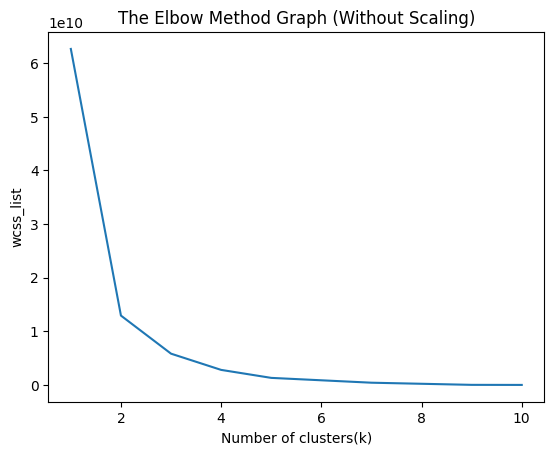

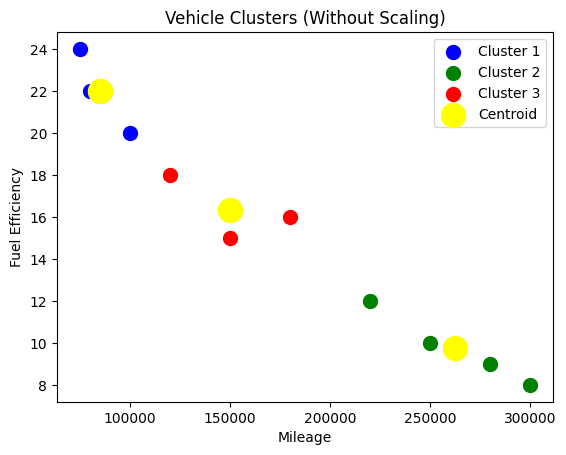

Clusters (without scaling):
   vehicle_serial_no vehicle_type  Cluster_NoScale
0                  5          SUV                2
1                  3        Sedan                2
2                  8        Truck                1
3                  2    Hatchback                0
4                  4        Sedan                0
5                  7        Truck                1
6                  6          SUV                2
7                 10        Truck                1
8                  1    Hatchback                0
9                  9          SUV                1

CLUSTERING WITH SCALING (except vehicle_type)


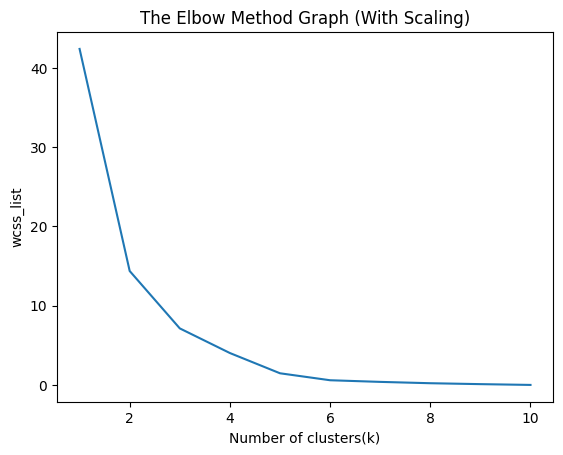

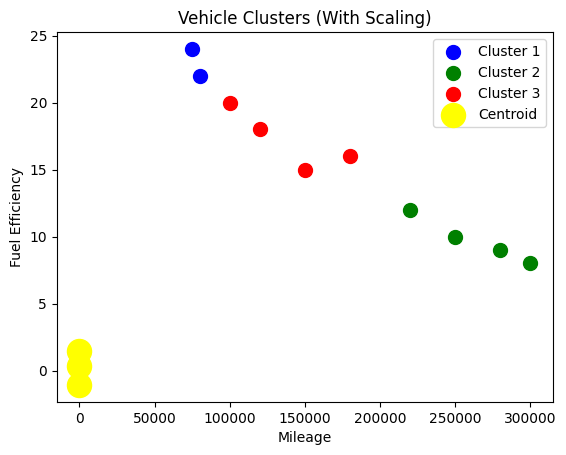

Clusters (with scaling):
   vehicle_serial_no vehicle_type  Cluster_NoScale  Cluster_Scaled
0                  5          SUV                2               2
1                  3        Sedan                2               2
2                  8        Truck                1               1
3                  2    Hatchback                0               0
4                  4        Sedan                0               2
5                  7        Truck                1               1
6                  6          SUV                2               2
7                 10        Truck                1               1
8                  1    Hatchback                0               0
9                  9          SUV                1               1


In [11]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage':           [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency':   [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost':  [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type':      ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)
print(df.head(10))

le = LabelEncoder()
df['vehicle_type_encoded'] = le.fit_transform(df['vehicle_type'])
print("\nVehicle Type Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

x = df[['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_encoded']].values

print("\nCLUSTERING WITHOUT SCALING")

wcss_list = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 11), wcss_list)
mtp.title('The Elbow Method Graph (Without Scaling)')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

kmeans_no_scale    = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_predict_no_scale = kmeans_no_scale.fit_predict(x)

mtp.scatter(x[y_predict_no_scale == 0, 0], x[y_predict_no_scale == 0, 1], s=100, c='blue',  label='Cluster 1')  #for first cluster
mtp.scatter(x[y_predict_no_scale == 1, 0], x[y_predict_no_scale == 1, 1], s=100, c='green', label='Cluster 2')  #for second cluster
mtp.scatter(x[y_predict_no_scale == 2, 0], x[y_predict_no_scale == 2, 1], s=100, c='red',   label='Cluster 3')  #for third cluster
mtp.scatter(kmeans_no_scale.cluster_centers_[:, 0], kmeans_no_scale.cluster_centers_[:, 1], s=300, c='yellow', label='Centroid')
mtp.title('Vehicle Clusters (Without Scaling)')
mtp.xlabel('Mileage')
mtp.ylabel('Fuel Efficiency')
mtp.legend()
mtp.show()

df['Cluster_NoScale'] = y_predict_no_scale
print("Clusters (without scaling):")
print(df[['vehicle_serial_no', 'vehicle_type', 'Cluster_NoScale']])

print("\nCLUSTERING WITH SCALING (except vehicle_type)")

x_to_scale = df[['mileage', 'fuel_efficiency', 'maintenance_cost']].values
x_cat      = df[['vehicle_type_encoded']].values

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(x_to_scale)
X_combined = nm.hstack([X_scaled, x_cat])

wcss_list = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_combined)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 11), wcss_list)
mtp.title('The Elbow Method Graph (With Scaling)')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

kmeans_scaled    = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_predict_scaled = kmeans_scaled.fit_predict(X_combined)

mtp.scatter(x[y_predict_scaled == 0, 0], x[y_predict_scaled == 0, 1], s=100, c='blue',  label='Cluster 1')  #for first cluster
mtp.scatter(x[y_predict_scaled == 1, 0], x[y_predict_scaled == 1, 1], s=100, c='green', label='Cluster 2')  #for second cluster
mtp.scatter(x[y_predict_scaled == 2, 0], x[y_predict_scaled == 2, 1], s=100, c='red',   label='Cluster 3')  #for third cluster
mtp.scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1], s=300, c='yellow', label='Centroid')
mtp.title('Vehicle Clusters (With Scaling)')
mtp.xlabel('Mileage')
mtp.ylabel('Fuel Efficiency')
mtp.legend()
mtp.show()

df['Cluster_Scaled'] = y_predict_scaled
print("Clusters (with scaling):")
print(df[['vehicle_serial_no', 'vehicle_type', 'Cluster_NoScale', 'Cluster_Scaled']])



## comparison:
##  WITHOUT Scaling:
##  - Mileage (75,000-300,000) completely dominates clustering.
##  - fuel_efficiency and vehicle_type are nearly ignored.
##  - Clusters are essentially just groupings by mileage alone.

##   WITH Scaling (except vehicle_type):
##  - Mileage, fuel_efficiency, maintenance_cost all contribute equally.
##    - Clusters reflect true usage patterns across all features.
##  - More meaningful groups: Trucks vs Sedans vs Hatchbacks by actual usage.

## Scaling is essential when features have very different ranges.


#TASK # 3
The academic affairs department at FAST NUCES Karachi is looking to identify distinct
groups of students based on their academic engagement and performance. The
department has access to anonymized student data containing the attributes student_id,
GPA, study_hours (average weekly study hours), and attendance_rate (percentage of classes attended).
The goal is to group students into meaningful clusters that can help tailor academic
support programs, such as extra tutoring, mentoring sessions, or motivation workshops.

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

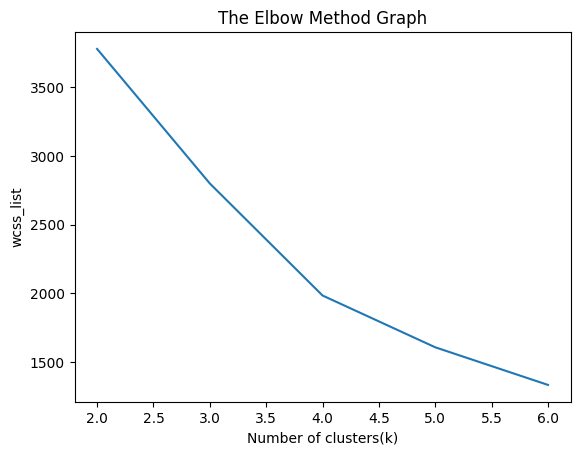

  K=2 -> WCSS: 3778.51
  K=3 -> WCSS: 2799.28
  K=4 -> WCSS: 1983.69
  K=5 -> WCSS: 1606.69
  K=6 -> WCSS: 1332.92

Optimal K selected: 3


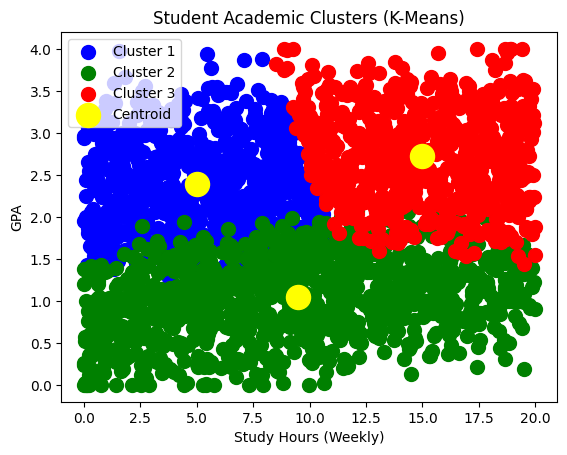


Final Dataset: Student IDs with Assigned Clusters
    StudentID       GPA  StudyTimeWeekly  attendance_rate  Cluster
0        1001  2.929196        19.833723            76.67        2
1        1002  3.042915        15.408756           100.00        2
2        1003  0.112602         4.210570            13.33        1
3        1004  2.054218        10.028829            53.33        0
4        1005  1.288061         4.672495            43.33        1
5        1006  3.084184         8.191219           100.00        0
6        1007  2.748237        15.601680            66.67        2
7        1008  1.360143        15.424496            26.67        1
8        1009  2.896819         4.562008            96.67        0
9        1010  3.573474        18.444466           100.00        2
10       1011  2.147172        11.851364            63.33        2
11       1012  1.559595         7.598486            50.00        1
12       1013  1.520078        10.038712            30.00        1
13       10

In [12]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('Student_performance_data _.csv')

print(df.head())
print(f"\nDataset Shape: {df.shape}")
print("\nColumn Names:", df.columns.tolist())

if 'StudentID' not in df.columns:
    df.insert(0, 'StudentID', range(1, len(df) + 1))

df['attendance_rate'] = ((30 - df['Absences']) / 30 * 100).round(2)

features = ['GPA', 'StudyTimeWeekly', 'attendance_rate']
x = df[features].copy()

print("\nSelected Features")
print(features)

print("\nMissing Values before handling:\n", x.isnull().sum())

for col in features:
    x[col] = x[col].fillna(x[col].median())

print("\nMissing Values after handling:\n", x.isnull().sum())

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(x)
print("\nStandard Scaling applied to all selected features.")

wcss_list = []

for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(2, 7), wcss_list)
mtp.title('The Elbow Method Graph')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

for k, wcss in zip(range(2, 7), wcss_list):
    print(f"  K={k} -> WCSS: {wcss:.2f}")

print("\nOptimal K selected: 3")

kmeans    = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_predict = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_predict

x_raw = x.values
mtp.scatter(x_raw[y_predict == 0, 1], x_raw[y_predict == 0, 0], s=100, c='blue',  label='Cluster 1')  #for first cluster
mtp.scatter(x_raw[y_predict == 1, 1], x_raw[y_predict == 1, 0], s=100, c='green', label='Cluster 2')  #for second cluster
mtp.scatter(x_raw[y_predict == 2, 1], x_raw[y_predict == 2, 0], s=100, c='red',   label='Cluster 3')  #for third cluster
mtp.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:, 1],
    scaler.inverse_transform(kmeans.cluster_centers_)[:, 0],
    s=300, c='yellow', label='Centroid'
)
mtp.title('Student Academic Clusters (K-Means)')
mtp.xlabel('Study Hours (Weekly)')
mtp.ylabel('GPA')
mtp.legend()
mtp.show()

print("\nFinal Dataset: Student IDs with Assigned Clusters")
print(df[['StudentID', 'GPA', 'StudyTimeWeekly',
          'attendance_rate', 'Cluster']].head(20).to_string())

print("\nCluster Summary")
print(df.groupby('Cluster')[features].mean().round(2).to_string())
